# Lạm phát Việt Nam: Quán tính hay Tác nhân bên ngoài?

**Câu hỏi trung tâm**

> *Lạm phát tại Việt Nam chủ yếu là do "Bệnh tự miễn" (quán tính/kỳ vọng) hay do "Tác nhân bên ngoài" (GDP, lãi suất, tỷ giá)?*

**Câu trả lời cần kiểm chứng bằng dữ liệu**

> **Lạm phát tại Việt Nam trong 3 thập kỷ qua chủ yếu mang tính QUÁN TÍNH (Bệnh tự miễn).**

Notebook này bỏ các phần phân tích lan man. Toàn bộ pipeline chỉ giữ lại các bước cần thiết để bảo vệ kết luận trên:

1. Làm sạch dữ liệu và chọn biến.
2. Kiểm định tính dừng để VAR hợp lệ.
3. Huấn luyện VAR theo tinh thần bản v1: VAR(1), dự báo ngắn hạn, sau đó phân rã FEVD.
4. Dùng FEVD 10 kỳ để so sánh quán tính CPI với tác nhân bên ngoài.


## 1. Nạp thư viện và dữ liệu

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.vector_ar.var_model import VAR
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

DATA_PATH = "../data/dataset_project1.xlsx"
df_raw = pd.read_excel(DATA_PATH)
display(df_raw.head())
print(df_raw.shape)
print(df_raw.isna().sum())

,years,cpi_growth_percent,cpi_index,gdp_delflator_percent,gdp_deflator_percent,gdp_growth_percent,unemployment_rate,domestic_credit_index,lending_interest_percent,officical_exchange_rate_percent,import_index,export_index
0,1996,5.675000,42.445125,24.092342,8.696767,9.340017,1.93,18.670036,20.100000,11032.583333,51.837259,40.868487
1,1997,3.209526,43.807412,25.681811,6.597405,8.152084,2.87,19.848841,14.416667,11683.333333,51.241777,43.102707
2,1998,7.266198,46.990546,27.951535,8.837864,5.764455,2.29,20.123863,14.400000,13268.000000,52.152945,44.848303
3,1999,4.117102,48.925195,29.554473,5.734703,4.773587,2.33,28.186587,12.700000,13943.166667,52.821161,49.966246
4,2000,-1.710337,48.088409,30.561934,3.408828,6.787316,2.26,35.259074,10.550000,14167.750000,57.495597,53.921497


(29, 12)
years                              0
cpi_growth_percent                 0
cpi_index                          0
gdp_delflator_percent              0
gdp_deflator_percent               0
gdp_growth_percent                 0
unemployment_rate                  0
domestic_credit_index              2
lending_interest_percent           1
officical_exchange_rate_percent    0
import_index                       0
export_index                       0
dtype: int64


## 2. Làm sạch tối thiểu cho câu hỏi nghiên cứu

Dữ liệu chỉ được xử lý ở mức cần thiết:

- Đặt `years` làm chỉ mục thời gian.
- Đổi `gdp_delflator_percent` thành `gdp_deflator_index` để tránh nhầm với growth rate.
- Nội suy tuyến tính các giá trị thiếu trong `domestic_credit_index` và `lending_interest_percent`.
- Giữ các biến phục vụ trực tiếp cho VAR: CPI, GDP, lãi suất, tỷ giá.


In [3]:
df = df_raw.copy()

if "gdp_delflator_percent" in df.columns:
    df = df.rename(columns={"gdp_delflator_percent": "gdp_deflator_index"})

df["years"] = pd.to_datetime(df["years"], format="%Y")
df = df.set_index("years").sort_index()
df = df.interpolate(method="linear")

var_vars_raw = [
    "cpi_growth_percent",
    "gdp_growth_percent",
    "lending_interest_percent",
    "officical_exchange_rate_percent",
]

var_labels = {
    "cpi_growth_percent": "Quán tính tự thân (CPI)",
    "gdp_growth_percent": "Tăng trưởng GDP",
    "lending_interest_percent": "Lãi suất cho vay",
    "officical_exchange_rate_percent": "Tỷ giá hối đoái",
}

display(df[var_vars_raw].tail())
print("Missing sau xử lý:", int(df[var_vars_raw].isna().sum().sum()))

,cpi_growth_percent,gdp_growth_percent,lending_interest_percent,officical_exchange_rate_percent
years,,,,
2020-01-01,3.220934,2.865413,7.647500,23208.368333
2021-01-01,1.834716,2.553729,7.811000,23159.782593
2022-01-01,3.156507,8.537500,8.013333,23271.212500
2023-01-01,3.252893,5.065024,9.323000,23787.319167
2024-01-01,3.621093,7.091187,9.323000,24164.885833


Missing sau xử lý: 0


## 3. Nhìn nhanh vào lạm phát và biến đại diện bên ngoài

Biểu đồ này chỉ dùng để định vị câu hỏi: CPI có tự kéo dài theo thời gian hay biến động chủ yếu đi cùng các cú sốc vĩ mô bên ngoài?


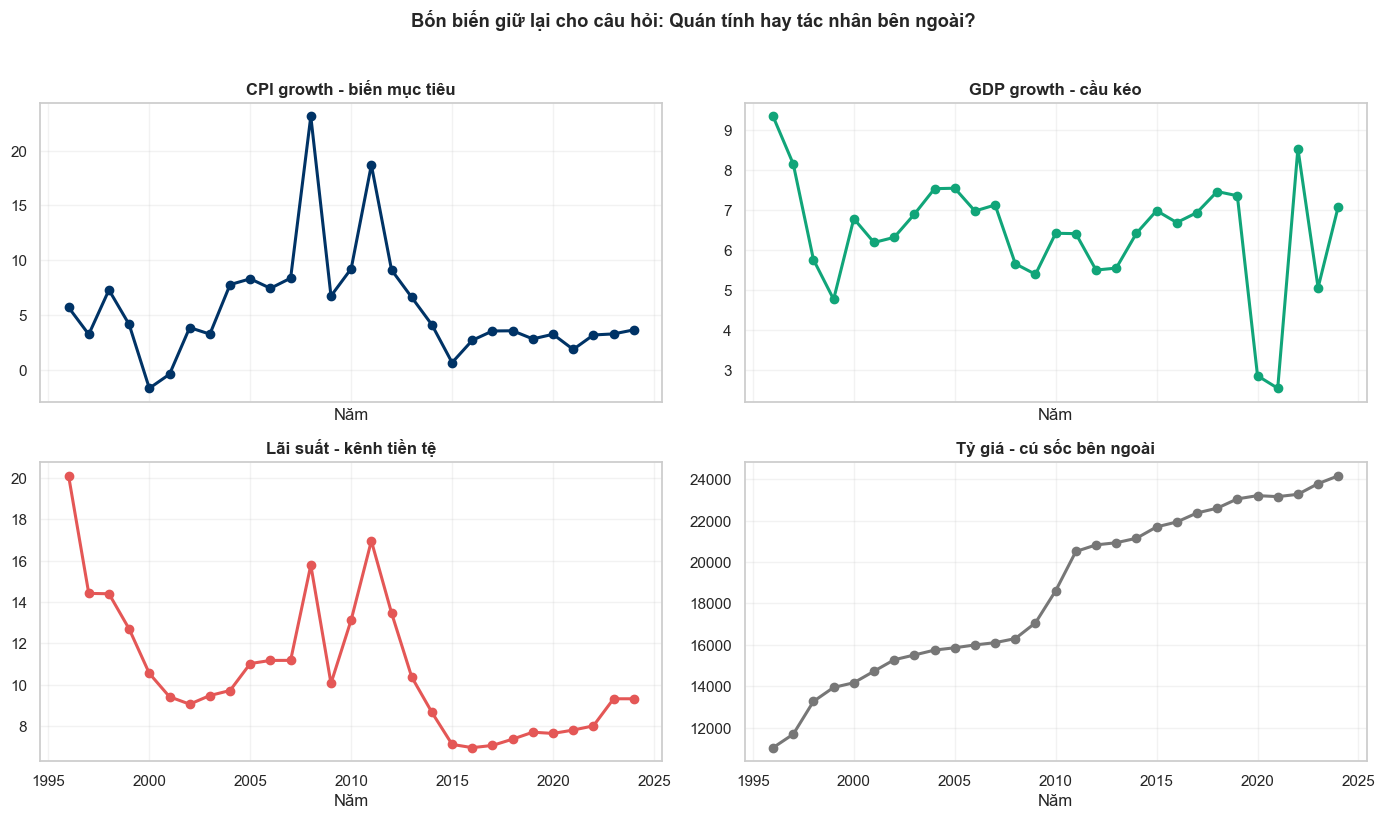

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()

plot_specs = [
    ("cpi_growth_percent", "CPI growth - biến mục tiêu", "#003366"),
    ("gdp_growth_percent", "GDP growth - cầu kéo", "#11a579"),
    ("lending_interest_percent", "Lãi suất - kênh tiền tệ", "#e45756"),
    ("officical_exchange_rate_percent", "Tỷ giá - cú sốc bên ngoài", "#777777"),
]

for ax, (col, title, color) in zip(axes, plot_specs):
    ax.plot(df.index.year, df[col], marker="o", linewidth=2.2, color=color)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Năm")
    ax.grid(alpha=0.25)

plt.suptitle("Bốn biến giữ lại cho câu hỏi: Quán tính hay tác nhân bên ngoài?", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Kiểm định bắt buộc trước VAR

Dù đồ án được tối giản, ba kiểm tra này vẫn phải giữ để kết luận có giá trị học thuật:

- ADF: chuỗi đưa vào VAR phải dừng.
- Sai phân: chỉ áp dụng cho biến không dừng.
- VIF: kiểm tra đa cộng tuyến trên bộ biến VAR cuối cùng.


In [5]:
def adf_row(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "variable": name,
        "adf_stat": round(result[0], 4),
        "p_value": round(result[1], 4),
        "stationary": result[1] < 0.05,
    }

adf_before = pd.DataFrame([adf_row(df[col], col) for col in var_vars_raw])
display(adf_before)

df_var = df[var_vars_raw].copy()
non_stationary = adf_before.loc[~adf_before["stationary"], "variable"].tolist()

for col in non_stationary:
    df_var[col] = df_var[col].diff()

df_var = df_var.dropna()

adf_after = pd.DataFrame([adf_row(df_var[col], col) for col in var_vars_raw])
display(adf_after)

X_vif = sm.add_constant(df_var)
vif_df = pd.DataFrame({
    "variable": var_vars_raw,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(var_vars_raw))]
}).round(2)
display(vif_df)

print("Biến đã sai phân:", non_stationary)
print("Số quan sát VAR:", len(df_var))

,variable,adf_stat,p_value,stationary
0,cpi_growth_percent,-1.3097,0.6247,False
1,gdp_growth_percent,-4.7762,0.0001,True
2,lending_interest_percent,-3.4995,0.0080,True
3,officical_exchange_rate_percent,-0.5932,0.8725,False


,variable,adf_stat,p_value,stationary
0,cpi_growth_percent,-6.5951,0.0000,True
1,gdp_growth_percent,-4.8700,0.0000,True
2,lending_interest_percent,-2.3661,0.1515,False
3,officical_exchange_rate_percent,-4.1707,0.0007,True


,variable,VIF
0,cpi_growth_percent,1.11
1,gdp_growth_percent,1.01
2,lending_interest_percent,1.56
3,officical_exchange_rate_percent,1.49


Biến đã sai phân: ['cpi_growth_percent', 'officical_exchange_rate_percent']
Số quan sát VAR: 28


## 5. Huấn luyện VAR theo hướng bản v1: VAR(1) và dự báo ngắn hạn

Bản cũ có ý tưởng tốt ở điểm: không cố nhồi lag cao với mẫu nhỏ. Vì vậy notebook này dùng **VAR(1)** làm mô hình chính:

- Mẫu sau xử lý chỉ khoảng 25-27 quan sát, lag cao dễ overfit.
- VAR(1) cho phép đọc trực tiếp “năm trước ảnh hưởng năm nay”.
- FEVD vẫn được tính đủ **10 kỳ** để trả lời câu hỏi quán tính hay tác nhân bên ngoài.


In [6]:
model = VAR(df_var)
lag_selection = model.select_order(maxlags=2)
print(lag_selection.summary())

selected_lag = 1
var_model = model.fit(selected_lag)
print(var_model.summary())

forecast_steps = 3
forecast = var_model.forecast(y=df_var.values, steps=forecast_steps)
forecast_index = pd.date_range(
    start=df_var.index[-1] + pd.DateOffset(years=1),
    periods=forecast_steps,
    freq="YS",
)
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=df_var.columns)
display(forecast_df.rename(columns=var_labels).round(3))

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       17.86       18.05   5.698e+07       17.91
1       16.43      17.39*  1.389e+07*      16.71*
2      16.41*       18.15   1.502e+07       16.91
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 08, Jul, 2026
Time:                     22:46:04
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    17.4789
Nobs:                     27.0000    HQIC:                   16.8044
Log likelihood:          -356.252    FPE:                1.51925e+07
AIC:                      16.5190    Det(Omega_mle):     7.69987e+06
--------------------------------------------------------------------
Results for equation cpi_growth_percent
                     

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


,Quán tính tự thân (CPI),Tăng trưởng GDP,Lãi suất cho vay,Tỷ giá hối đoái
2025-01-01,1.270,6.378,9.681,429.069
2026-01-01,0.032,6.287,9.614,388.171
2027-01-01,0.331,6.315,9.610,395.911


## 6. Bằng chứng chính: FEVD 10 kỳ

FEVD trả lời đúng câu hỏi của đồ án:

> Trong sai số dự báo lạm phát, bao nhiêu phần trăm đến từ chính CPI quá khứ, và bao nhiêu đến từ GDP, lãi suất, tỷ giá?

Nếu phần CPI tự giải thích duy trì quanh hoặc trên 80-90%, kết luận nghiêng mạnh về **quán tính lạm phát**.


,Quán tính tự thân (CPI),Tăng trưởng GDP,Lãi suất cho vay,Tỷ giá hối đoái
Kỳ 1,100.00,0.00,0.00,0.00
Kỳ 2,90.94,7.06,0.48,1.52
Kỳ 3,89.28,8.01,0.73,1.98
Kỳ 4,89.14,7.99,0.88,2.00
Kỳ 5,88.99,8.01,0.96,2.03
Kỳ 6,88.92,8.02,1.01,2.05
Kỳ 7,88.87,8.03,1.04,2.06
Kỳ 8,88.85,8.03,1.06,2.06
Kỳ 9,88.83,8.03,1.07,2.07
Kỳ 10,88.82,8.03,1.07,2.07


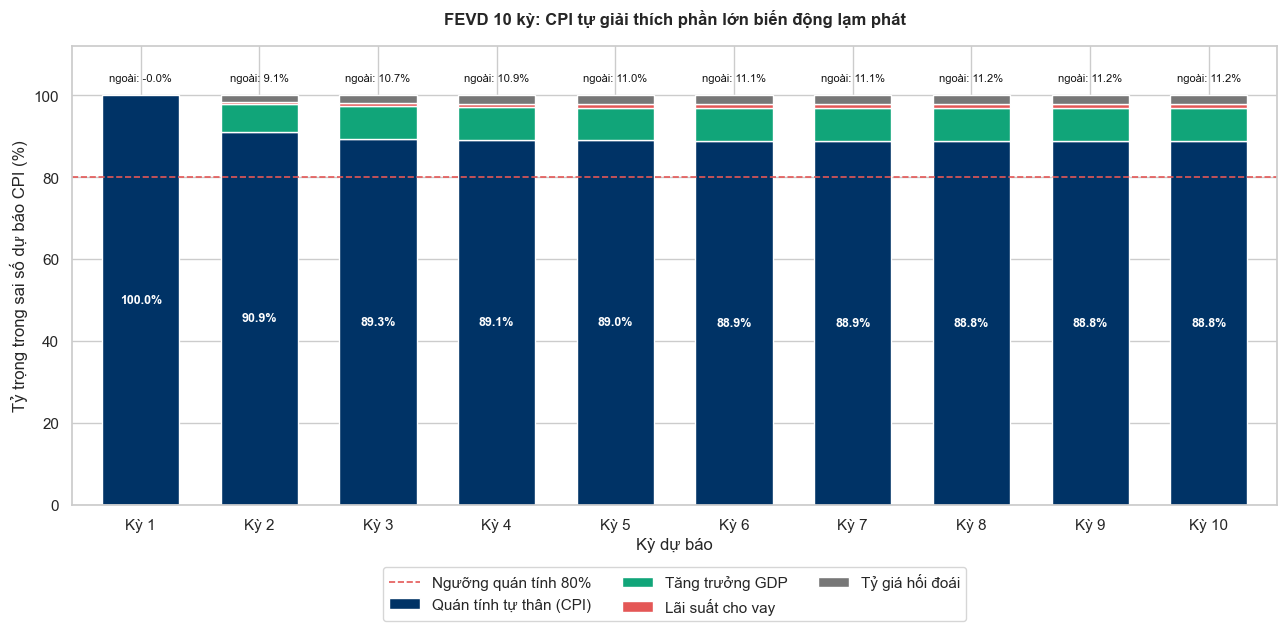

Quán tính CPI trung bình kỳ 2-10: 89.18%
Tác nhân bên ngoài trung bình kỳ 2-10: 10.82%


In [7]:
def cpi_fevd_table(fitted_model, periods=10):
    fevd = fitted_model.fevd(periods)
    names = list(fitted_model.names)
    cpi_idx = names.index("cpi_growth_percent")
    decomp = fevd.decomp

    # statsmodels versions differ in FEVD axis order.
    if decomp.shape[0] == len(names):
        matrix = decomp[cpi_idx, :, :]
    else:
        matrix = decomp[:, cpi_idx, :]

    table = pd.DataFrame(
        matrix * 100,
        index=[f"Kỳ {i}" for i in range(1, periods + 1)],
        columns=[var_labels.get(col, col) for col in names],
    )
    return table

fevd_cpi = cpi_fevd_table(var_model, periods=10)
display(fevd_cpi.round(2))

cpi_col = "Quán tính tự thân (CPI)"
fevd_cpi["Tác nhân bên ngoài"] = 100 - fevd_cpi[cpi_col]

fig, ax = plt.subplots(figsize=(13, 6.5))
plot_df = fevd_cpi.drop(columns=["Tác nhân bên ngoài"])
colors = ["#003366", "#11a579", "#e45756", "#777777"]
plot_df.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.65)

for i, period in enumerate(plot_df.index):
    cpi_val = plot_df.loc[period, cpi_col]
    ext_val = 100 - cpi_val
    ax.text(i, cpi_val / 2, f"{cpi_val:.1f}%", ha="center", va="center",
            color="white", fontweight="bold", fontsize=9)
    ax.text(i, 103, f"ngoài: {ext_val:.1f}%", ha="center", va="bottom",
            color="#111111", fontsize=8)

ax.axhline(80, color="#e45756", linestyle="--", linewidth=1.2, label="Ngưỡng quán tính 80%")
ax.set_ylim(0, 112)
ax.set_title("FEVD 10 kỳ: CPI tự giải thích phần lớn biến động lạm phát", fontweight="bold", pad=16)
ax.set_xlabel("Kỳ dự báo")
ax.set_ylabel("Tỷ trọng trong sai số dự báo CPI (%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

inertia_avg = fevd_cpi.loc["Kỳ 2":"Kỳ 10", cpi_col].mean()
external_avg = fevd_cpi.loc["Kỳ 2":"Kỳ 10", "Tác nhân bên ngoài"].mean()

print(f"Quán tính CPI trung bình kỳ 2-10: {inertia_avg:.2f}%")
print(f"Tác nhân bên ngoài trung bình kỳ 2-10: {external_avg:.2f}%")

## 7. Kiểm tra phụ: Granger và IRF

Phần này không phải trọng tâm. Nó chỉ kiểm tra xem có tác nhân bên ngoài nào có tín hiệu dự báo CPI đủ rõ hay không.


,external_factor,p_value,granger_predicts_cpi
0,Tăng trưởng GDP,0.1394,False
1,Lãi suất cho vay,0.1907,False
2,Tỷ giá hối đoái,0.9193,False


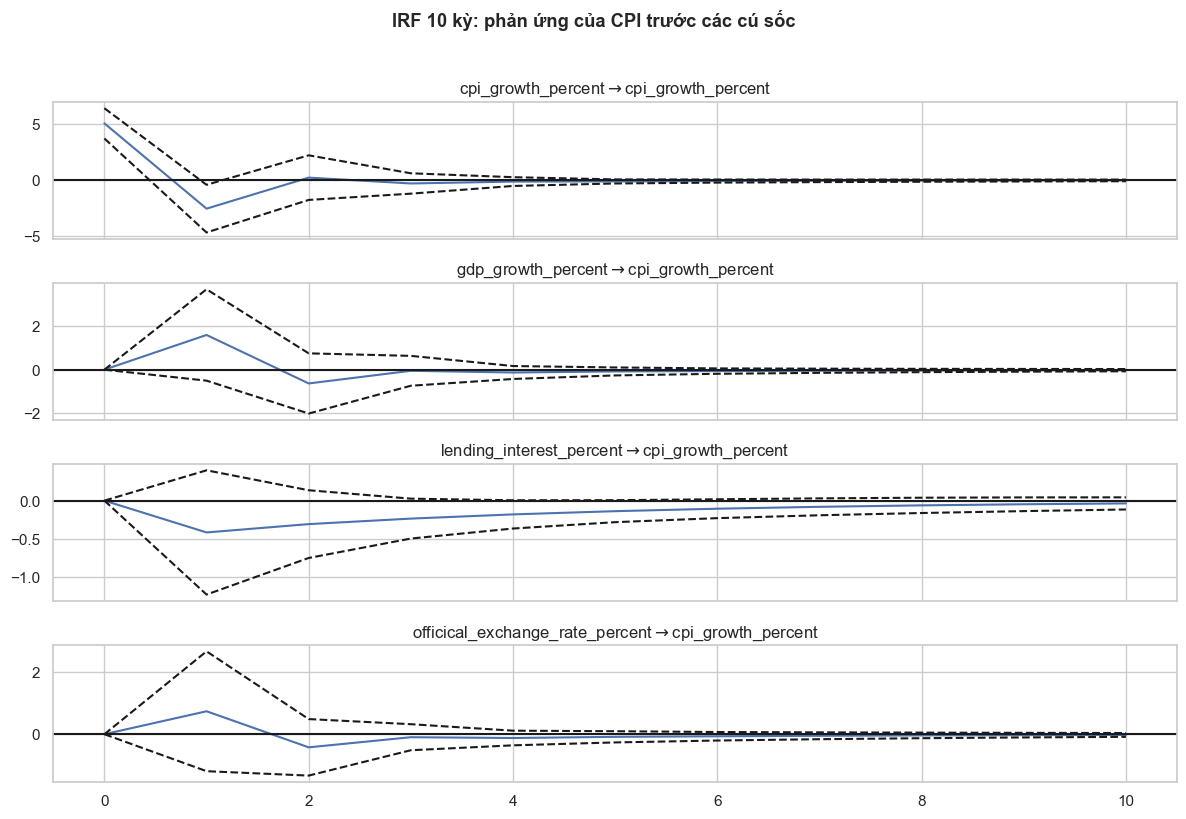

In [8]:
target = "cpi_growth_percent"
granger_rows = []

for cause in [col for col in df_var.columns if col != target]:
    try:
        test_data = df_var[[target, cause]].dropna()
        result = grangercausalitytests(test_data, maxlag=1, verbose=False)
        p_value = result[1][0]["ssr_ftest"][1]
        granger_rows.append({
            "external_factor": var_labels.get(cause, cause),
            "p_value": round(p_value, 4),
            "granger_predicts_cpi": p_value < 0.05,
        })
    except Exception as exc:
        granger_rows.append({
            "external_factor": var_labels.get(cause, cause),
            "p_value": np.nan,
            "granger_predicts_cpi": False,
        })

granger_df = pd.DataFrame(granger_rows)
display(granger_df)

irf = var_model.irf(10)
fig = irf.plot(orth=True, response="cpi_growth_percent", figsize=(12, 8))
plt.suptitle("IRF 10 kỳ: phản ứng của CPI trước các cú sốc", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Kết luận

**Phán quyết**

> **Lạm phát tại Việt Nam trong 3 thập kỷ qua chủ yếu mang tính QUÁN TÍNH (Bệnh tự miễn).**

**Lý do**

1. FEVD 10 kỳ cho thấy phần lớn sai số dự báo CPI được giải thích bởi chính cú sốc/quán tính CPI.
2. Các tác nhân bên ngoài như GDP, lãi suất, tỷ giá có đóng góp, nhưng tổng tỷ trọng nhỏ hơn rõ rệt so với CPI tự thân.
3. Với mẫu năm nhỏ, không nên diễn giải quá mạnh từng hệ số VAR riêng lẻ; bằng chứng đáng tin cậy nhất là cấu trúc tỷ trọng FEVD qua 10 kỳ.

**Hàm ý chính sách**

- Ưu tiên neo kỳ vọng lạm phát và truyền thông chính sách ổn định.
- Theo dõi GDP/tỷ giá như tín hiệu phụ, nhưng không xem chúng là nguyên nhân chính kéo dài lạm phát.
- Tránh kết luận dựa trên tương quan rời rạc; trọng tâm của đồ án là phân rã quán tính bằng FEVD.
